# Phase 2: Building Machine Learning Models
## Decision Tree Classifier

In this notebook, we will train a **Decision Tree** on our data. 

**Why Decision Trees?**
Unlike Regression (which draws a mathematical line through the data), Decision Trees act like a giant flow-chart or a game of "20 Questions". 
* They don't require feature scaling (MinMax or Standard) to work, but we use the scaled data here to maintain a 1:1 comparison with our other models.
* They automatically find non-linear patterns.
* They are highly interpretable but prone to over-fitting if they grow too deep.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

## 1. Load the Data

In [16]:
data = pd.read_csv('Telco-Customer-Churn-MinMax.csv')
df = pd.DataFrame(data)
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,0.013889,0,1,0.11,0.003339,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,0.472222,1,0,0.38,0.217526,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,0.027778,1,1,0.35,0.012437,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,0.625000,0,0,0.24,0.211884,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0.027778,1,1,0.52,0.017388,1,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,0.333333,1,1,0.66,0.229157,0,...,1,0,1,0,1,1,0,0,0,1
7039,0,0,1,1,1.000000,1,1,0.85,0.847766,0,...,0,0,1,0,1,1,0,1,0,0
7040,0,0,1,1,0.152778,0,1,0.11,0.039843,0,...,0,0,0,0,0,0,0,0,1,0
7041,1,1,1,0,0.055556,1,1,0.56,0.035237,1,...,0,0,0,0,0,0,0,0,0,1


## 2. Train-Test Split (Data Segregation)
We split our data: $80\%$ for training, $20\%$ for testing. `random_state=42` ensures reproducible results.

In [17]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Data Size:", X_train.shape) 
print("Testing Data Size:", X_test.shape)

Training Data Size: (5634, 30)
Testing Data Size: (1409, 30)


## 3. Training a Decision Tree Classifier
Here we initialize our model using `DecisionTreeClassifier`. 

**How it works mathematically (Gini Impurity):**
The tree looks at all possible splits for every feature (e.g., `Tenure > 12`) and calculates the **Gini Impurity** of the resulting child nodes. It continually chooses the split that creates the purest (most uniform) groups of `Churn` vs `No Churn`.
*   $$Gini = 1 - \sum (p_i)^2$$
*   A Gini of $0.0$ means the group is perfectly pure (all customers in that leaf either strictly churned or strictly didn't).


  **Deep Dive into Gini Impurity:**
  * **What is $p_i$?** It is the *probability* (or fraction) of randomly picking a specific class (like Churn vs No Churn) in a specific group.
    * If a leaf node has 10 people, and 3 are Churners and 7 are Non-Churners...
    * $p_{\text{churn}} = \frac{3}{10} = 0.3$
    * $p_{\text{no-churn}} = \frac{7}{10} = 0.7$
  * **How is it Calculated?** Using the example above:
    * $$Gini = 1 - ( (0.3)^2 + (0.7)^2 )$$
    * $$Gini = 1 - ( 0.09 + 0.49 )$$
    * $$Gini = 1 - 0.58 = \mathbf{0.42}$$
  * **Why is it useful?** The Gini Index measures how "mixed up" a group is. 
    * A Gini of **$0.0$** is the ultimate goal. It means the node is $100\%$ pure (e.g., all 10 people are Churners). The tree is absolutely certain of its prediction.
    * A Gini of **$0.5$** is the worst possible score. It means the node is a perfect $50/50$ split. The tree is completely guessing.
    * The Decision Tree algorithm looks at thousands of possible questions (e.g. "Is Tenure > 12?", "Is MonthlyCharges > 50?"), calculates the Gini for the "Yes" leaf and the "No" leaf, and permanently locks in the question that drops the Gini Index the closest to $0.0$!
*Note: Without setting `max_depth`, this tree will grow until every single leaf is $100\%$ pure, which usually causes it to memorize the training data perfectly (Overfitting).*

In [19]:
model = DecisionTreeClassifier()
model

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

## 4. Understanding Classification Metrics
Because we are predicting strict categories (`1` or `0`), we use **Classification Metrics** to measure the *count* of correct vs. incorrect buckets.

**1. The Confusion Matrix**
* **True Positives (TP):** We predicted Churn ($1$), and they actually Churned ($1$).
* **True Negatives (TN):** We predicted No Churn ($0$), and they actually Didn't Churn ($0$).
* **False Positives (FP) [Type I Error]:** We predicted Churn ($1$), but they Didn't Churn ($0$). *(False Alarm)*
* **False Negatives (FN) [Type II Error]:** We predicted No Churn ($0$), but they actually Churned ($1$). *(Missed Opportunity)*

**2. Accuracy Score**
$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

**3. Precision & Recall & F1**
* **Precision:** Quality of positive predictions. $\frac{TP}{TP + FP}$
* **Recall:** Quantity of positive predictions found. $\frac{TP}{TP + FN}$
* **F1-Score:** The harmonic mean of Precision and Recall. $2 \times \frac{Precision \times Recall}{Precision + Recall}$

Accuracy Score: 0.7203690560681334

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.82      0.81      1036
           1       0.47      0.45      0.46       373

    accuracy                           0.72      1409
   macro avg       0.64      0.63      0.64      1409
weighted avg       0.72      0.72      0.72      1409



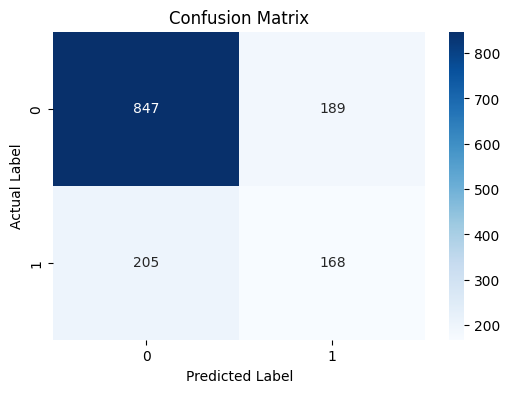

In [20]:
model.fit(X_train, y_train)
y_test_pred = model.predict(X_test)
y_test_pred = (y_test_pred > 0.5).astype(int)

# 1. Accuracy Score
print("Accuracy Score:", accuracy_score(y_test, y_test_pred))

# 2. Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))

# 3. Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6,4))
sb.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()